In [175]:
import pandas as pd
import ast
import matplotlib.pyplot as plt


In [176]:
all_students = pd.read_csv('students.csv') 
all_students.head()

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt
0,[],2025-03-20T18:38:30.804031,carla340@student.revoducate.edu,2024,10,781893021,Carla Hughes,241-896-9377x830,SCH104631,0.0,student,2025-03-20T18:38:30.804031
1,[],2025-03-20T18:38:30.804031,tony502@student.revoducate.edu,2022,12,675695845,Tony Erickson,+1-590-808-0644x2427,SCH104631,0.0,student,2025-03-20T18:38:30.804031
2,[],2025-03-20T18:38:30.804031,diane915@student.revoducate.edu,2023,11,700822744,Diane Mccarthy,642-904-6049x306,SCH104631,0.0,student,2025-03-20T18:38:30.804031
3,[],2025-03-20T18:38:30.804031,erin533@student.revoducate.edu,2023,11,492881063,Erin Sanders,(392)693-5809x920,SCH104631,0.0,student,2025-03-20T18:38:30.804031
4,[],2025-03-20T18:38:30.804031,kathleen12@student.revoducate.edu,2024,10,583493751,Kathleen Hanson,(456)718-0695,SCH104631,0.0,student,2025-03-20T18:38:30.804031


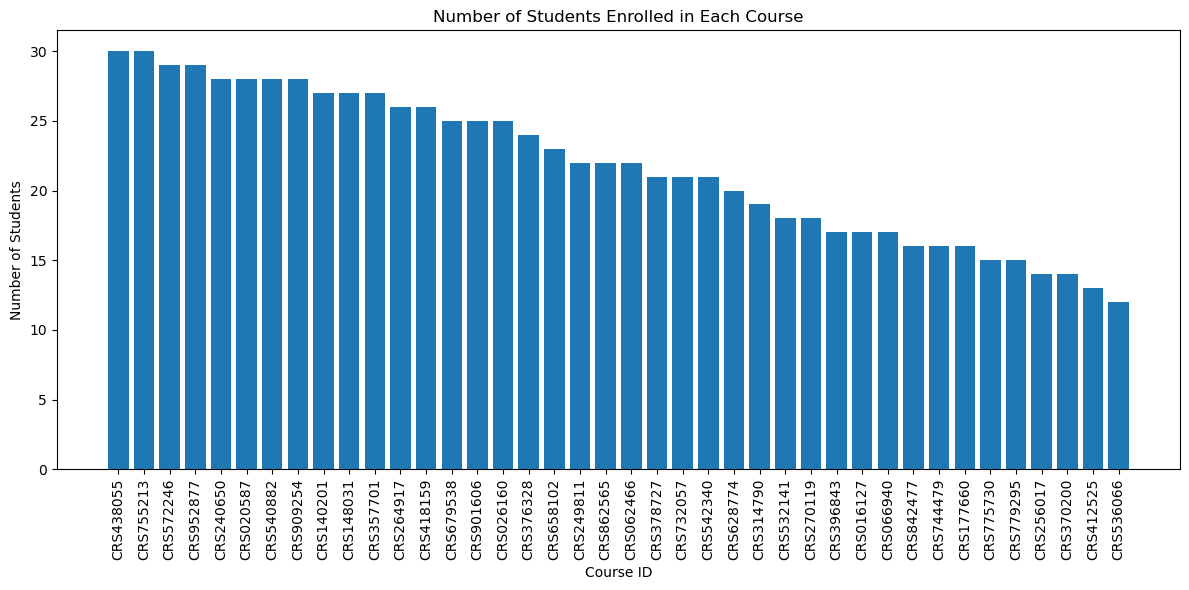

       Course  Student Count
0   CRS438055             30
1   CRS755213             30
2   CRS572246             29
3   CRS952877             29
4   CRS240650             28
5   CRS020587             28
6   CRS540882             28
7   CRS909254             28
8   CRS140201             27
9   CRS148031             27
10  CRS357701             27
11  CRS264917             26
12  CRS418159             26
13  CRS679538             25
14  CRS901606             25
15  CRS026160             25
16  CRS376328             24
17  CRS658102             23
18  CRS249811             22
19  CRS862565             22
20  CRS062466             22
21  CRS378727             21
22  CRS732057             21
23  CRS542340             21
24  CRS628774             20
25  CRS314790             19
26  CRS532141             18
27  CRS270119             18
28  CRS396843             17
29  CRS016127             17
30  CRS066940             17
31  CRS842477             16
32  CRS744479             16
33  CRS177660 

In [177]:

# Assuming all_students is your existing DataFrame
# Convert the string representation of courses to actual lists
all_students['parsed_courses'] = all_students['courses'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the DataFrame so each student-course pair gets its own row
student_courses = all_students.explode('parsed_courses')

# Count the number of students per course
course_counts = student_courses['parsed_courses'].value_counts().reset_index()
course_counts.columns = ['Course', 'Student Count']

# Create the plot
plt.figure(figsize=(12, 6))
plt.bar(course_counts['Course'], course_counts['Student Count'])
plt.xlabel('Course ID')
plt.ylabel('Number of Students')
plt.title('Number of Students Enrolled in Each Course')
plt.xticks(rotation=90)
plt.tight_layout()

# Display the plot
plt.show()

# Print the data for reference
print(course_counts)

In [178]:
all_courses = set()

# Parse the 'courses' column for each student
for course_str in all_students['courses']:
    try:
        # Parse the string representation of a list
        courses = ast.literal_eval(course_str)
        # Add each course to the set
        for course in courses:
            all_courses.add(course)
    except:
        # Skip rows with parsing issues
        continue

# Count the number of different courses
num_different_courses = len(all_courses)
print(f"Number of different courses: {num_different_courses}")
print("List of courses:", sorted(all_courses))

Number of different courses: 40
List of courses: ['CRS016127', 'CRS020587', 'CRS026160', 'CRS062466', 'CRS066940', 'CRS140201', 'CRS148031', 'CRS177660', 'CRS240650', 'CRS249811', 'CRS256017', 'CRS264917', 'CRS270119', 'CRS314790', 'CRS357701', 'CRS370200', 'CRS376328', 'CRS378727', 'CRS396843', 'CRS412525', 'CRS418159', 'CRS438055', 'CRS532141', 'CRS536066', 'CRS540882', 'CRS542340', 'CRS572246', 'CRS628774', 'CRS658102', 'CRS679538', 'CRS732057', 'CRS744479', 'CRS755213', 'CRS775730', 'CRS779295', 'CRS842477', 'CRS862565', 'CRS901606', 'CRS909254', 'CRS952877']


In [179]:
all_assignments = pd.read_csv('assignments.csv')

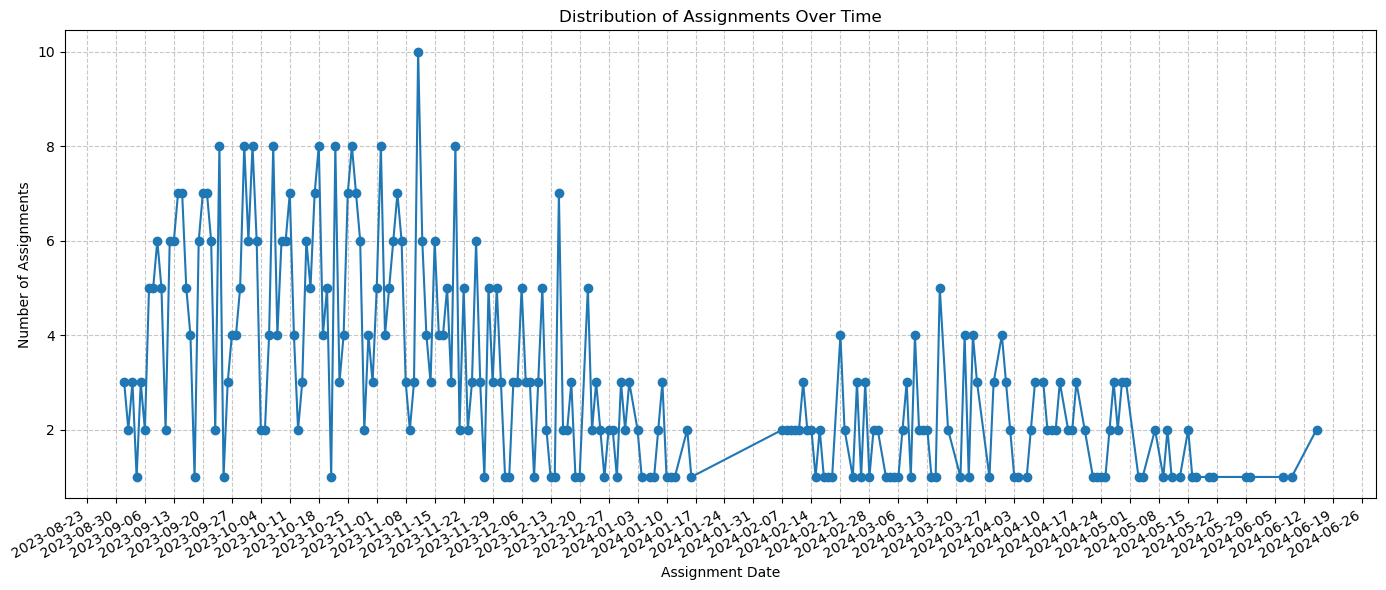

In [180]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Assuming all_assignments is your DataFrame with an 'assignDate' column

# Convert 'assignDate' to datetime if it's not already
all_assignments['assignDate'] = pd.to_datetime(all_assignments['assignDate'])

# Sort by date
all_assignments_sorted = all_assignments.sort_values('assignDate')

# Count assignments per date
assignments_by_date = all_assignments.groupby('assignDate').size().reset_index(name='count')

# Plot
plt.figure(figsize=(14, 6))
plt.plot(assignments_by_date['assignDate'], assignments_by_date['count'], marker='o')

# Format the x-axis to show dates clearly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))  # Show tick every 7 days
plt.gcf().autofmt_xdate()  # Rotate date labels

# Add labels and title
plt.xlabel('Assignment Date')
plt.ylabel('Number of Assignments')
plt.title('Distribution of Assignments Over Time')
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

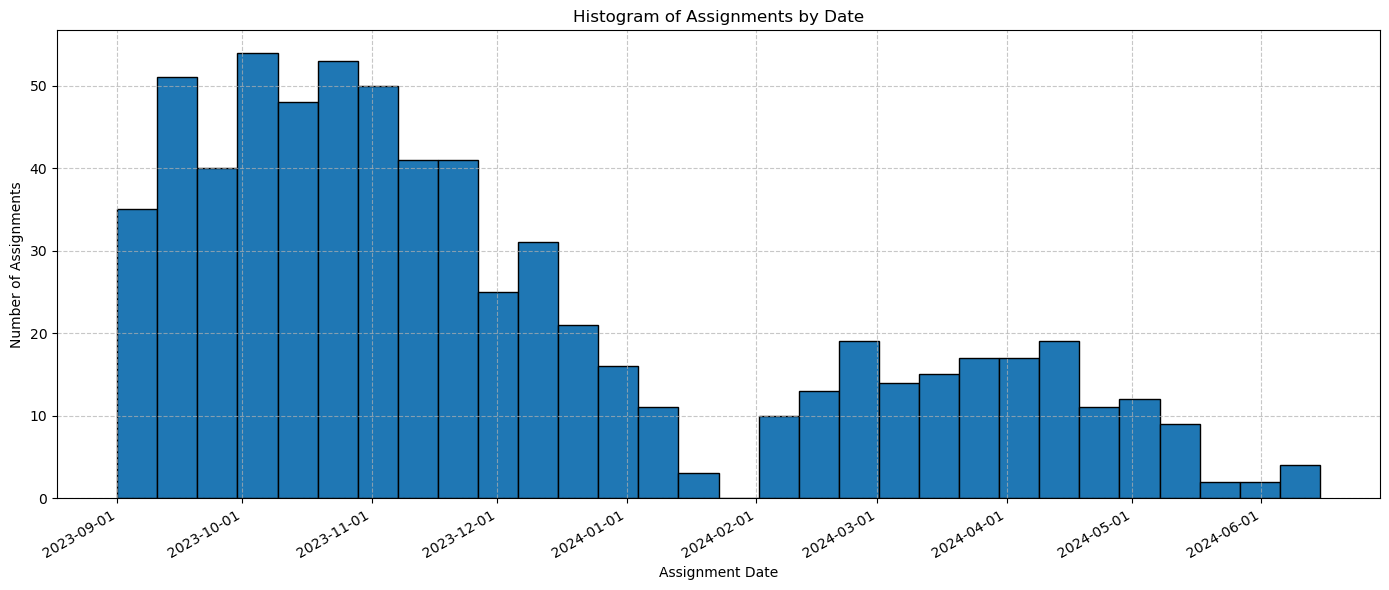

In [181]:
plt.figure(figsize=(14, 6))
plt.hist(all_assignments['assignDate'], bins=30, edgecolor='black')
plt.xlabel('Assignment Date')
plt.ylabel('Number of Assignments')
plt.title('Histogram of Assignments by Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [182]:
all_students = all_students[all_students['parsed_courses'].apply(len) > 0]
all_students

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt,parsed_courses
9,"[""CRS572246""]",2025-03-20T18:38:30.805035,george735@student.revoducate.edu,2023,11,232541144,George Richmond,212.792.5345x205,SCH104631,65.5,student,2025-03-20T18:38:31.187769,[CRS572246]
41,"[""CRS572246""]",2025-03-20T18:38:30.807035,nicole189@student.revoducate.edu,2025,9,880292242,Nicole Coleman,+1-381-618-9580x22656,SCH104631,78.2,student,2025-03-20T18:38:31.187769,[CRS572246]
42,"[""CRS370200""]",2025-03-20T18:38:30.807035,john998@student.revoducate.edu,2023,11,808966727,John Murray,262.559.7241x982,SCH104631,89.3,student,2025-03-20T18:38:31.187769,[CRS370200]
51,"[""CRS177660""]",2025-03-20T18:38:30.808035,lindsay109@student.revoducate.edu,2024,10,857507848,Lindsay Reese,568-516-1520x5247,SCH104631,53.6,student,2025-03-20T18:38:31.188768,[CRS177660]
64,"[""CRS177660"", ""CRS572246""]",2025-03-20T18:38:30.809035,john884@student.revoducate.edu,2025,9,398931816,John Flowers,239.996.5220x0641,SCH104631,75.5,student,2025-03-20T18:38:31.188768,"[CRS177660, CRS572246]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4303,"[""CRS628774""]",2025-03-20T18:38:31.163749,rachel526@student.אורטחקלאיפרדסחנה.edu,2024,10,235524716,Rachel Shepard,770.768.7817x99541,SCH783413,79.3,student,2025-03-20T18:38:31.700387,[CRS628774]
4307,"[""CRS909254""]",2025-03-20T18:38:31.164753,kimberly35@student.אורטחקלאיפרדסחנה.edu,2022,12,889166471,Kimberly Jones,(309)843-0093,SCH783413,100.0,student,2025-03-20T18:38:31.700387,[CRS909254]
4315,"[""CRS732057""]",2025-03-20T18:38:31.164753,michael426@student.אורטחקלאיפרדסחנה.edu,2022,12,101141633,Michael Simpson,(702)634-0384x107,SCH783413,95.2,student,2025-03-20T18:38:31.701387,[CRS732057]
4316,"[""CRS016127""]",2025-03-20T18:38:31.164753,jennifer928@student.אורטחקלאיפרדסחנה.edu,2023,11,960281912,Jennifer Lowery,(288)958-8396x318,SCH783413,55.3,student,2025-03-20T18:38:31.702387,[CRS016127]


In [183]:
##students by grade
students_by_grade = all_students['totalScore'].value_counts().reset_index()
students_by_grade.columns = ['Grade', 'Student Count']
students_by_grade = students_by_grade.sort_values('Grade')
students_by_grade.to_csv('students_by_grade.csv', index=False)

In [184]:
studentwithzero = all_students[all_students['totalScore'] == 0]
studentwithzero

,courses,createdAt,email,entryYear,gradeLevel,id,name,phone,schoolId,totalScore,type,updatedAt,parsed_courses


In [185]:
all_students = pd.read_csv('students.csv')

In [186]:
student_assignments = pd.read_csv('studentAssignments.csv')
student_assignments.head()

,assessmentScore,assignmentId,createdAt,id,isLate,studentId,submissionDate,timeSpentMinutes,updatedAt
0,67.5,ASG895281,2025-03-20T18:38:31.186770,sa_dfc3b599,False,232541144,2024-02-13T00:00:00,157.0,2025-03-20T18:38:31.186770
1,56.0,ASG397563,2025-03-20T18:38:31.186770,sa_a87b96d4,True,232541144,2024-02-26T00:00:00,101.0,2025-03-20T18:38:31.186770
2,65.4,ASG996408,2025-03-20T18:38:31.186770,sa_0779b28e,False,232541144,2024-03-02T00:00:00,84.0,2025-03-20T18:38:31.186770
3,71.8,ASG333932,2025-03-20T18:38:31.186770,sa_815cda3d,False,232541144,2024-03-03T00:00:00,126.0,2025-03-20T18:38:31.186770
4,65.3,ASG825870,2025-03-20T18:38:31.186770,sa_3b476c0e,True,232541144,2024-03-15T00:00:00,97.0,2025-03-20T18:38:31.186770


In [187]:
## find student by id in student_assignments
student_id = 380215769
student_assignments[student_assignments['studentId'] == student_id]


,assessmentScore,assignmentId,createdAt,id,isLate,studentId,submissionDate,timeSpentMinutes,updatedAt


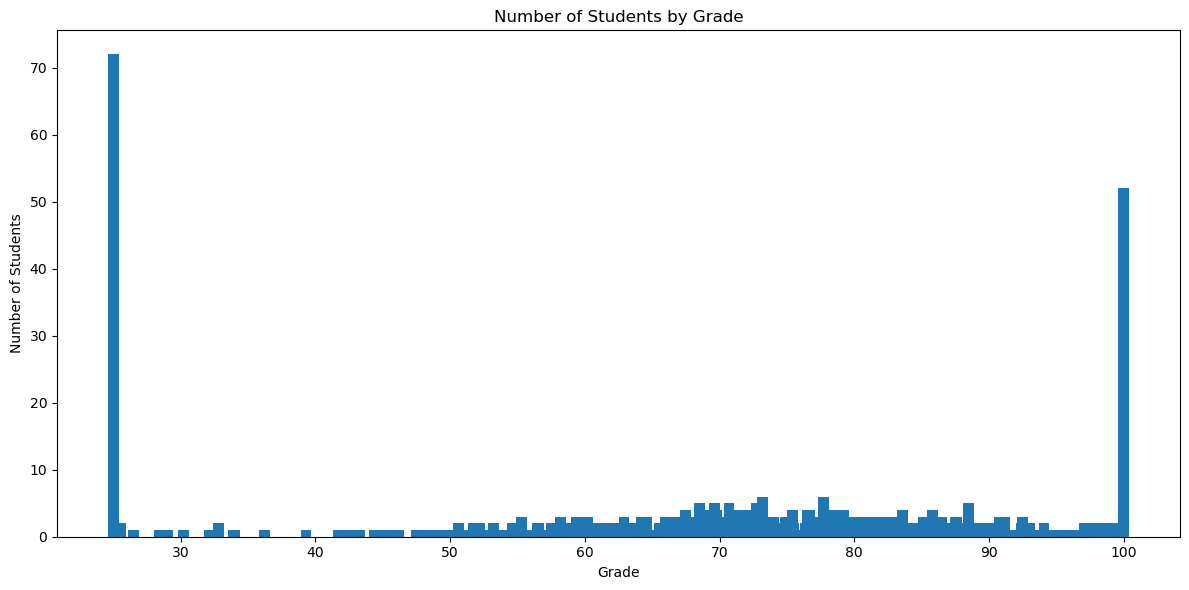

In [188]:
##plotting students by grade
plt.figure(figsize=(12, 6))
plt.bar(students_by_grade['Grade'], students_by_grade['Student Count'])
plt.xlabel('Grade')
plt.ylabel('Number of Students')

plt.title('Number of Students by Grade')
plt.tight_layout()
plt.show()
